# Examine Clusters

This notebook is for examining the clustering algorithm used by Spyral. To use this notebook you *must* first have run the PointcloudPhase of Spyral and generated those results. The clustering algorithm will be applied to the point clouds and plots will be displayed showing the results. This is useful for tuning the various clustering parameters. Note that data generated here is NOT saved. This is only for testing. For more informations on phases checkout the [documentation](https://attpc.github.io/Spyral/).

## Configuration
First we import all the things

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from attpc_estimator.process.line_distance import ransac_inlier_mask

from attpc_storage.hdf5 import PointcloudReader

%matplotlib widget

# Utility for syncing plot colors
DEFAULT_COLORS = plt.rcParams["axes.prop_cycle"].by_key()["color"]
def get_color(value: int) -> str:
    color_index = value
    if color_index >= len(DEFAULT_COLORS):
        color_index = color_index % len(DEFAULT_COLORS)
    elif color_index == -1:
        return "black"
    return DEFAULT_COLORS[color_index]
figs = [None]*8

def fit_line(data: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
	"""Fit a line to the data using RANSAC.

	Args:
		data (np.ndarray): The data to fit.

	Returns:
		centroid (np.ndarray): The centroid of the line.z
		direction (np.ndarray): The direction of the line.
	"""
	centroid = np.mean(data, axis=0)
	centered = data - centroid
	covraiance = np.dot(centered.T, centered) / len(data)
	eigenvalues, eigenvectors = np.linalg.eigh(covraiance)
	direction = eigenvectors[:, -1]
	return centroid, direction

def point_from_line(z: float, centroid: np.ndarray, direction: np.ndarray) -> np.ndarray:
	"""Calculate the point on the line with the given z-coordinate.

	Args:
		z (float): The z-coordinate of the point.

	Returns:
		np.ndarray: The point on the line.
	"""
	alpha = (z - centroid[2]) / direction[2]
	return centroid + alpha * direction

def point_line_distance(point: np.ndarray, centroid: np.ndarray, direction: np.ndarray) -> float | np.ndarray:
	"""Calculate the distance of the point to the line.

	Args:
		point (np.ndarray): The point to calculate.
		centroid (np.ndarray): The centroid of the line.
		direction (np.ndarray): The direction of the line.

	Returns:
		float: The direction of the point to the line.
		or
		np.ndarray: The distances of the points to the line.
	"""
	diff = point - centroid
	if point.ndim == 1:
		cross_product = np.cross(diff, direction)
		distance = np.linalg.norm(cross_product, axis=0)
		return float(distance)
	diff_cross_dir = np.cross(diff, direction)
	distance = np.linalg.norm(diff_cross_dir, axis=1)
	return distance

def projection_z(point: np.ndarray, start: np.ndarray, direction: np.ndarray) -> float:
	"""Calculate the z-coordinate of the projection of the point on the line.

	Args:
		point (np.ndarray): The point to calculate.
		start (np.ndarray): The start point of the line.
		direction (np.ndarray): The direction of the line.

	Returns:
		float: The z-coordinate of the projection of the point on the line.
	"""
	return np.dot(point - start, direction)




Now we'll load the point clouds generated by phase one. This is very similar to the previous example where we loaded traces, so please reference that section if anything is unclear.

We use the PointcloudReader directly, which is derived from Hdf5Reader.

In [2]:
run_number = 1056
reader = PointcloudReader(
	workspace="/data/rcnp2025/attpc_estimator/",
	run=run_number,
	path="pointcloud/run_<run>.h5",
)
min_event, max_event = reader.get_range()
print(f"First event: {min_event} Last event: {max_event}")

First event: 0 Last event: 27506


## Analysis

Re-runing the code below this cell will allow you to walk through the dataset in order, as long as you do not re-run the cells  above this!

Now we'll load the next event in the dataset (or a specific hardcoded one)

In [28]:
event = None
# You can hardcode a specific event to debug
# event = np.random.randint(min_event, max_event)
if event is None:
    meta, event_data = reader.read()
else:
    meta, event_data = reader.read_event(event)
print(meta)
cloud = event_data[:]
print(cloud.shape)

(2, 1056, 2)
(398, 9)


Below we plot the 3D xyz,Q view and 2D xy,Q view of single event.

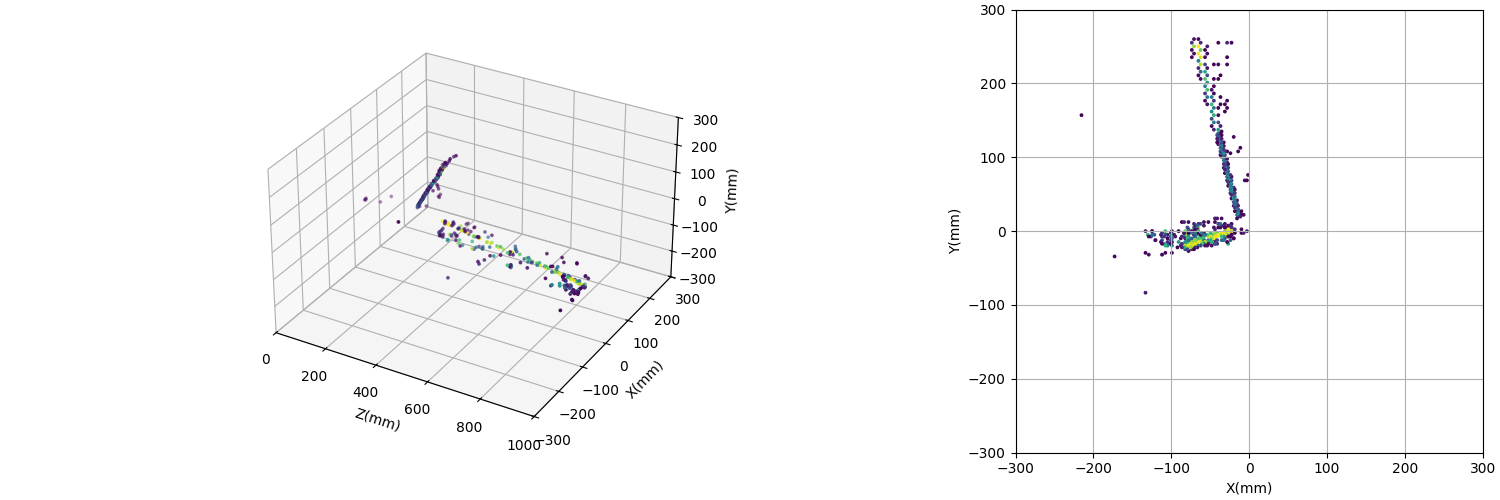

In [29]:
fig, axs = plt.subplot_mosaic(
    """
    AAB
    """,
    per_subplot_kw={
        "A": {
            "projection": "3d",
            "box_aspect": (2,1,1),
            "aspect": "equalxy"
        }
    },
    figsize=(15.0, 5.0),
    constrained_layout=True
)
axs["A"].scatter(cloud[:, 2], cloud[:, 0], cloud[:, 1], c=cloud[:, 3], s=3, label="Pointcloud")
axs["A"].set_xlim3d(0., 1000.0)
axs["A"].set_xlabel("Z(mm)")
axs["A"].set_ylim3d(-300.0, 300.0)
axs["A"].set_ylabel("X(mm)")
axs["A"].set_zlim3d(-300.0, 300.0)
axs["A"].set_zlabel("Y(mm)")
axs["B"].scatter(cloud[:, 0], cloud[:, 1], c=cloud[:, 3], s=3)
axs["B"].set_xlim(-300.0, 300.0)
axs["B"].set_xlabel("X(mm)")
axs["B"].set_ylim(-300.0, 300.0)
axs["B"].set_ylabel("Y(mm)")
axs["B"].grid()

Then we try RANSAC to find particle.

In [30]:
clusters: list[tuple] = []
# # ransac = linear_model.ransacregressor(
# # 	min_samples=3,
# # 	residual_threshold=20.0,
# # 	max_trials=200,
# # )
rng = np.random.default_rng(0)
unlabeled_data = cloud.copy()
origin_size = unlabeled_data.shape[0]
unlabeled_indices = np.arange(origin_size)
labeled_size = 0
labeled_ratio = 0.0
iter = 0
while (iter < 10 and labeled_ratio < 0.8):
	# ransac.fit(unlabeled_data[:, :2], unlabeled_data[:, 2])
	inliner_mask = ransac_inlier_mask(
		unlabeled_data[:, :3],
		residual_threshold=20.0,
		max_trials=50,
		start_radius=40.0,
		rng=rng
	)
	if inliner_mask.sum() < 20:
		iter += 1
		continue
	new_cluster = unlabeled_data[inliner_mask, :].copy()
	# starter = np.sqrt(new_cluster[0, 0]**2 + new_cluster[0, 1]**2)
	# if starter >= 40:
	# 	iter += 1
	# 	continue
	clusters.append((
		len(clusters),
		new_cluster,
		unlabeled_indices[inliner_mask].copy()
	))
	unlabeled_data = unlabeled_data[~inliner_mask, :]
	unlabeled_indices = unlabeled_indices[~inliner_mask]
	labeled_size += inliner_mask.sum()
	labeled_ratio = labeled_size / origin_size
	iter += 1
	print(
		f"iter: {iter}, "
		f"labeled_size {labeled_size}, "
		f"labeled_ratio: {labeled_ratio}, "
		f"labeled clusters {len(clusters)}"
	)

iter: 1, labeled_size 163, labeled_ratio: 0.40954773869346733, labeled clusters 1
iter: 2, labeled_size 194, labeled_ratio: 0.48743718592964824, labeled clusters 2
iter: 4, labeled_size 218, labeled_ratio: 0.5477386934673367, labeled clusters 3
iter: 7, labeled_size 240, labeled_ratio: 0.6030150753768844, labeled clusters 4


We can then plot the clusters together to check the performance of the algorithm

Cluster 0, size 163
Cluster 1, size 31
Cluster 2, size 24
Cluster 3, size 22


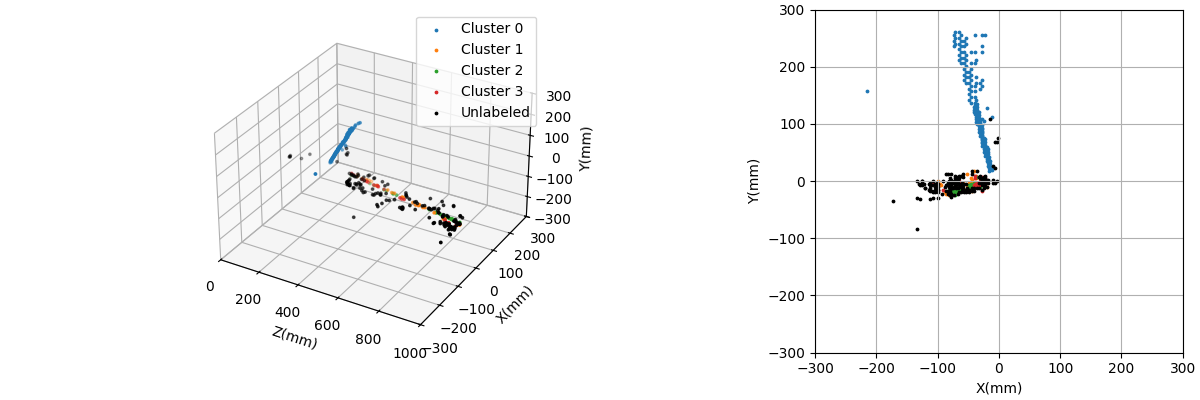

In [31]:
if figs[1] is not None:
    plt.close(figs[1])
figs[1], axs = plt.subplot_mosaic(
    """
    AAB
    """,
    per_subplot_kw={
        "A": {
            "projection": "3d",
            "box_aspect": (2,1,1),
            "aspect": "equalxy"
        }
    },
    figsize=(12.0, 4.0),
    constrained_layout=True
)

for cluster in clusters:
    print(f"Cluster {cluster[0]}, size {cluster[1].shape[0]}")
    axs["A"].scatter(
        cluster[1][:, 2],
        cluster[1][:, 0],
        cluster[1][:, 1],
        c=get_color(cluster[0]), s=3, label=f"Cluster {cluster[0]}"
    )
    axs["B"].scatter(cluster[1][:, 0], cluster[1][:, 1], c=get_color(cluster[0]), s=3, label=f"Cluster {cluster[0]}")
axs["A"].scatter(unlabeled_data[:, 2], unlabeled_data[:, 0], unlabeled_data[:, 1], c=get_color(-1), s=3, label="Unlabeled")
axs["B"].scatter(unlabeled_data[:, 0], unlabeled_data[:, 1], c=get_color(-1), s=3, label="Unlabeled")
axs["A"].set_xlim3d(0., 1000.0)
axs["A"].set_xlabel("Z(mm)")
axs["A"].set_ylim3d(-300.0, 300.0)
axs["A"].set_ylabel("X(mm)")
axs["A"].set_zlim3d(-300.0, 300.0)
axs["A"].set_zlabel("Y(mm)")
axs["B"].set_xlim(-300.0, 300.0)
axs["B"].set_xlabel("X(mm)")
axs["B"].set_ylim(-300.0, 300.0)
axs["B"].set_ylabel("Y(mm)")
axs["B"].grid()
axs["A"].legend()

Above shows the different clusters identified by the algorithm, with the labels supplied by the algorithm. Points labeled -1 were identified to be noise. 

Then we check the parameters of each line, and try to find connection between them. It is obvious that some of the cluster are noised and some are overlapped with the real one. We'd better find out a method to rule out the noise.

In [ ]:
centroids = np.zeros((len(clusters), 3))
directions = np.zeros((len(clusters), 3))
for cluster in clusters:
	centroid, direction = fit_line(cluster[1][:, :3])
	centroids[cluster[0], :3] = centroid
	directions[cluster[0], :3] = direction
print(centroids)
print(directions)

diff = centroids[:, None, :] - centroids[None, :, :]
cross = np.cross(diff, directions)
distances = np.linalg.norm(cross, axis=-1)
dot_product = np.clip(directions @ directions.T, -1.0, 1.0)
angle = np.degrees(np.arccos(dot_product))
mask = np.triu(np.ones((len(clusters), len(clusters)), dtype=bool), k=1)
distances = distances[mask]
angle = angle[mask]
print(distances)
print(angle)
merge_mask = (distances < 15.0) & (angle < 3.0)
print(merge_mask)

cleaned_clusters = []
cleaned_labels = [-1] * len(clusters)
mindex = 0
for i in range(len(clusters)):
	if cleaned_labels[i] == -1:
		cleaned_clusters.append((
			len(cleaned_clusters),
			clusters[i][1].copy(),
			clusters[i][2].copy()
		))
		cleaned_labels[i] = len(cleaned_clusters) - 1
	for j in range(i + 1, len(clusters)):
		if merge_mask[mindex] and cleaned_labels[j] == -1:
			label = cleaned_labels[i]
			cleaned_clusters[label] = (
				label,
				np.vstack((cleaned_clusters[label][1], clusters[j][1])),
				np.concatenate((cleaned_clusters[label][2], clusters[j][2]))
			)
			cleaned_labels[j] = label
		mindex += 1

[[-37.75173916 131.66416088 354.19345358]
 [-56.99536031  -5.4623908  693.16206297]
 [-63.46465881 -12.78186247 798.77744511]
 [-48.56052859  -4.9082352  598.39412085]]
[[-0.16733437  0.81237898  0.55860505]
 [-0.1158846  -0.04231009  0.99236113]
 [-0.08724873 -0.03216881  0.99566703]
 [-0.13882823 -0.02598068  0.98997562]]
[124.31688088 130.71955355 132.25667207   4.79706105   5.17506332
  13.33682046]
[57.360082   56.99917727 56.28033334  1.75090893  1.6193573   2.99463054]
[False False False  True  True  True]


Cluster 0, size 163
Cluster 1, size 77


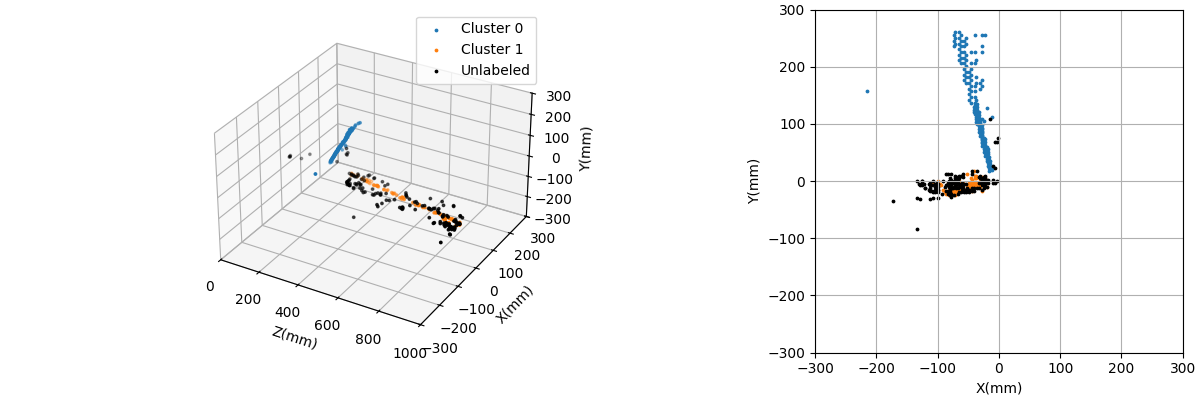

In [33]:
if figs[2] is not None:
    plt.close(figs[2])
figs[2], axs = plt.subplot_mosaic(
    """
    AAB
    """,
    per_subplot_kw={
        "A": {
            "projection": "3d",
            "box_aspect": (2,1,1),
            "aspect": "equalxy"
        }
    },
    figsize=(12.0, 4.0),
    constrained_layout=True
)

for cluster in cleaned_clusters:
    print(f"Cluster {cluster[0]}, size {cluster[1].shape[0]}")
    axs["A"].scatter(
        cluster[1][:, 2],
        cluster[1][:, 0],
        cluster[1][:, 1],
        c=get_color(cluster[0]), s=3, label=f"Cluster {cluster[0]}"
    )
    axs["B"].scatter(cluster[1][:, 0], cluster[1][:, 1], c=get_color(cluster[0]), s=3, label=f"Cluster {cluster[0]}")
axs["A"].scatter(unlabeled_data[:, 2], unlabeled_data[:, 0], unlabeled_data[:, 1], c=get_color(-1), s=3, label="Unlabeled")
axs["B"].scatter(unlabeled_data[:, 0], unlabeled_data[:, 1], c=get_color(-1), s=3, label="Unlabeled")
axs["A"].set_xlim3d(0., 1000.0)
axs["A"].set_xlabel("Z(mm)")
axs["A"].set_ylim3d(-300.0, 300.0)
axs["A"].set_ylabel("X(mm)")
axs["A"].set_zlim3d(-300.0, 300.0)
axs["A"].set_zlabel("Y(mm)")
axs["B"].set_xlim(-300.0, 300.0)
axs["B"].set_xlabel("X(mm)")
axs["B"].set_ylim(-300.0, 300.0)
axs["B"].set_ylabel("Y(mm)")
axs["B"].grid()
axs["A"].legend()

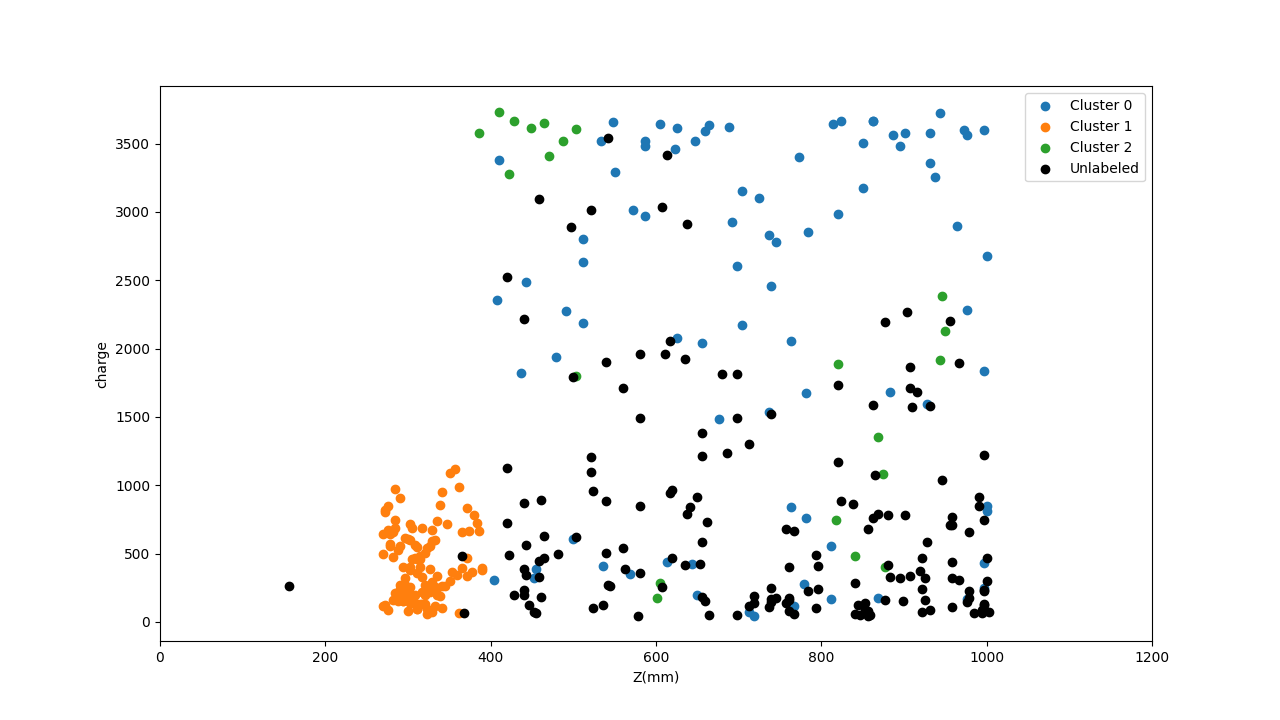

In [ ]:
# if figs[2] is not None:
# 	plt.close(figs[2])
# figs[2], ax = plt.subplots(1, 1, figsize=(12.8, 7.2))
# for cluster in clusters:
# 	ax.scatter(cluster[1][:, 2], cluster[1][:, 3], label=f"Cluster {cluster[0]}")
# 	ax.set_xlabel("Z(mm)")
# 	ax.set_xlim(0., 1200.0)
# 	ax.set_ylabel("charge")
# ax.scatter(unlabeled_data[:, 2], unlabeled_data[:, 3], c=get_color(-1), label="Unlabeled")
# ax.legend()

Now we can again plot our clusters

In [9]:
# clusters, labels = form_clusters(cloud, cluster_params)
# joined_clusters, labels = join_clusters(clusters, cluster_params, labels)
# fig, axs = plt.subplot_mosaic(
#     """
#     AAB
#     """,
#     per_subplot_kw={
#         "A": {
#             "projection": "3d", 
#             "box_aspect": (2,1,1),
#             "aspect": "equalxy"
#         }
#     },
#     figsize=(12.0, 4.0),
#     constrained_layout=True
# )

# for cluster in joined_clusters:
#     axs["A"].scatter(cluster.point_cloud.data[:, 2], cluster.point_cloud.data[:, 0], cluster.point_cloud.data[:, 1], c=get_color(cluster.label), s=3, label=f"Cluster {cluster.label}")
#     axs["B"].scatter(cluster.point_cloud.data[:, 0], cluster.point_cloud.data[:, 1], c=get_color(cluster.label), s=3, label=f"Cluster {cluster.label}")
# axs["A"].set_xlim3d(0., 1000.0)
# axs["A"].set_xlabel("Z(mm)")
# axs["A"].set_ylim3d(-300.0, 300.0)
# axs["A"].set_ylabel("X(mm)")
# axs["A"].set_zlim3d(-300.0, 300.0)
# axs["A"].set_zlabel("Y(mm)")
# axs["B"].set_xlim(-300.0, 300.0)
# axs["B"].set_xlabel("X(mm)")
# axs["B"].set_ylim(-300.0, 300.0)
# axs["B"].set_ylabel("Y(mm)")
# axs["B"].grid()
# # axs["A"].legend()

Now you should see well defined trajectory clusters! If you don't, try tweaking some of the parameters or cycling to a different point cloud.

Finally, a cleanup pass is run on the joined clusters to reduce noise. Note that we change types here. Previously our clusters were of type LabeledCloud, a temporary holding type. Now our clusters are of type Cluster, so the semantics change a small amount.

In [10]:
# cleaned_clusters, labels = cleanup_clusters(joined_clusters, cluster_params, labels)

We can again plot our projections to examine the results

In [11]:
# fig, axs = plt.subplot_mosaic(
#     """
#     AAB
#     """,
#     per_subplot_kw={
#         "A": {
#             "projection": "3d", 
#             "box_aspect": (2,1,1),
#             "aspect": "equalxy"
#         }
#     },
#     figsize=(12.0, 4.0),
#     constrained_layout=True
# )

# for cluster in cleaned_clusters:
#     axs["A"].scatter(cluster.data[:, 2], cluster.data[:, 0], cluster.data[:, 1], c=get_color(cluster.label), s=3, label=f"Cluster {cluster.label}")
#     axs["B"].scatter(cluster.data[:, 0], cluster.data[:, 1], c=get_color(cluster.label), s=3, label=f"Cluster {cluster.label}")
# axs["A"].set_xlim3d(0., 1000.0)
# axs["A"].set_xlabel("Z(mm)")
# axs["A"].set_ylim3d(-300.0, 300.0)
# axs["A"].set_ylabel("X(mm)")
# axs["A"].set_zlim3d(-300.0, 300.0)
# axs["A"].set_zlabel("Y(mm)")
# axs["B"].set_xlim(-300.0, 300.0)
# axs["B"].set_xlabel("X(mm)")
# axs["B"].set_ylim(-300.0, 300.0)
# axs["B"].set_ylabel("Y(mm)")
# axs["B"].grid()
# # axs["A"].legend()

If you re-run the cells in the Analysis section, you'll walk through the dataset in order

### Conclusion

We've now generated clusters from our point clouds and tested the parameters, so now you can take these parameters and run the full phase 2 analysis. The next step is perfom basic physics analysis and estimate some pararameters.